# Day 1 — Baseline Model

## Objective

Build a simple baseline classification model for cardiovascular disease prediction.

The baseline provides a reference performance that future models, including the neural network, should aim to improve upon.

## Tasks

- Load the cleaned dataset
- Define features and target
- Split the data into training and testing sets
- Scale the numerical features
- Train a Logistic Regression model
- Evaluate the model
- Record the baseline performance

In [7]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)
from sklearn.pipeline import Pipeline
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("cardio_cleaned.csv")

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (68742, 13)


,id,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,age_years
0,0,2,168,62.0,110,80,1,1,0,0,1,0,50.357290
1,1,1,156,85.0,140,90,3,1,0,0,1,1,55.381246
2,2,1,165,64.0,130,70,3,1,0,0,0,1,51.627652
3,3,2,169,82.0,150,100,1,1,0,0,1,1,48.249144
4,4,1,156,56.0,100,60,1,1,0,0,0,0,47.841205


## Features and Target

The target variable is cardio, which indicates whether the patient has cardiovascular disease.

The id column is excluded because it is an identifier and does not contain meaningful predictive information.

In [3]:
X = df.drop(columns=["cardio", "id"])
y = df["cardio"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (68742, 11)
Target shape: (68742,)


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

## 5-Fold Cross-Validation

Five-fold stratified cross-validation is used to evaluate the baseline model more reliably.

The training data is divided into five folds. In each iteration, four folds are used for training and one fold is used for validation. This process is repeated five times so that every fold is used once for validation.

The test set remains untouched until the final evaluation.

In [8]:
baseline_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        random_state=42,
        max_iter=1000
    ))
])

In [9]:
skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_results = cross_validate(
    baseline_pipeline,
    X_train,
    y_train,
    cv=skf,
    scoring=["accuracy", "precision", "recall", "f1"]
)

In [10]:
print("5-Fold Cross-Validation Results:\n")

print(f"Accuracy:  {cv_results['test_accuracy'].mean():.4f} ± {cv_results['test_accuracy'].std():.4f}")
print(f"Precision: {cv_results['test_precision'].mean():.4f} ± {cv_results['test_precision'].std():.4f}")
print(f"Recall:    {cv_results['test_recall'].mean():.4f} ± {cv_results['test_recall'].std():.4f}")
print(f"F1-score:  {cv_results['test_f1'].mean():.4f} ± {cv_results['test_f1'].std():.4f}")

5-Fold Cross-Validation Results:

Accuracy:  0.7269 ± 0.0044
Precision: 0.7525 ± 0.0031
Recall:    0.6679 ± 0.0092
F1-score:  0.7077 ± 0.0061


In [11]:
baseline_pipeline.fit(X_train, y_train)

y_pred = baseline_pipeline.predict(X_test)

In [12]:
print("Final Test Performance:")

print(f"Accuracy:  {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred):.4f}")
print(f"F1-score:  {f1_score(y_test, y_pred):.4f}")

Final Test Performance:
Accuracy:  0.7270
Precision: 0.7524
Recall:    0.6685
F1-score:  0.7080


## Confusion Matrix

The confusion matrix is used to examine the baseline model's classification performance on the unseen test set.

It shows the number of correctly and incorrectly classified patients for each class.

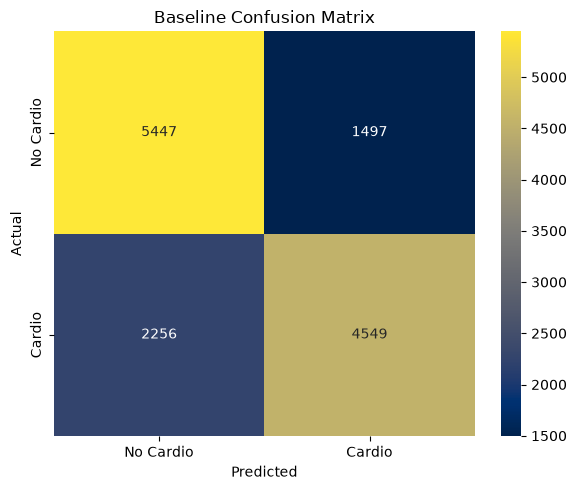

In [13]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="cividis",
    xticklabels=["No Cardio", "Cardio"],
    yticklabels=["No Cardio", "Cardio"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Baseline Confusion Matrix")

plt.tight_layout()
plt.show()

## Baseline Summary

Logistic Regression was selected as the baseline model for cardiovascular disease prediction.

The model was evaluated using stratified 5-fold cross-validation on the training set, followed by a final evaluation on the held-out test set.

The mean 5-fold F1-score is used as the main baseline metric for comparison with future models.

In [14]:
cv_f1_mean = cv_results["test_f1"].mean()
cv_f1_std = cv_results["test_f1"].std()

test_f1 = f1_score(y_test, y_pred)

print(f"5-Fold CV F1-score: {cv_f1_mean:.4f} ± {cv_f1_std:.4f}")
print(f"Test F1-score:      {test_f1:.4f}")

5-Fold CV F1-score: 0.7077 ± 0.0061
Test F1-score:      0.7080


## Baseline Target

**Baseline Model:** Logistic Regression

**5-Fold CV F1-score:** 0.7077 ± 0.0061

**Test F1-score:** 0.7080

The Logistic Regression model establishes the baseline performance for the project.

Future models, including the neural network, should aim to outperform this baseline.